<a href="https://colab.research.google.com/github/ShrimantiGawande/python_programming/blob/main/RF_on_50k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--> Loading dataset...
Dataset successfully loaded. Shape: (50000, 21)
--> Training Random Forest Model (This may take a minute with 50k rows)...
Model training complete!

     MACHINE LEARNING MODEL METRICS     
Formula Implemented via Data:
  • Metals:   Vr = (Vi² - Vbl²)^(1/2)
  • Ceramics: Vr = (Vi^1.5 - Vbl^1.5)^(2/3)
  • Noise:    ±2.5% Gaussian scatter applied
----------------------------------------
R² Score (Coefficient of Determination): 0.99846
Mean Absolute Error (MAE):               7.8159 m/s
Mean Squared Error (MSE):                193.4690 (m/s)²
Root Mean Squared Error (RMSE):          13.9093 m/s

--> Generating evaluation plots...


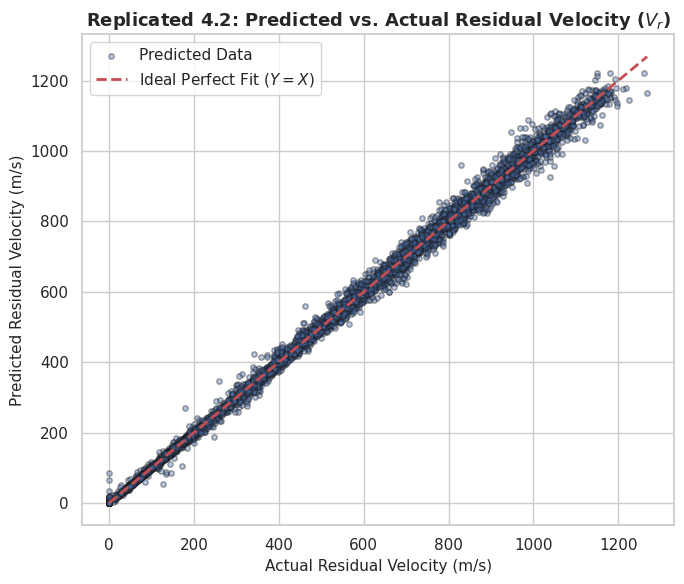

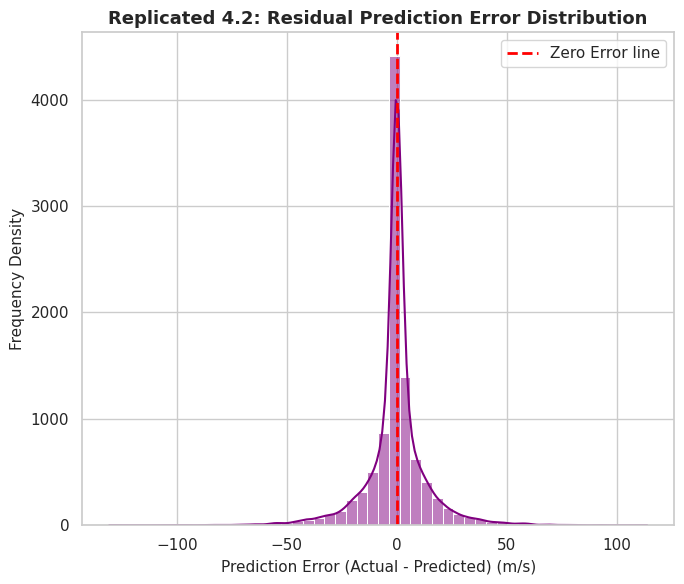

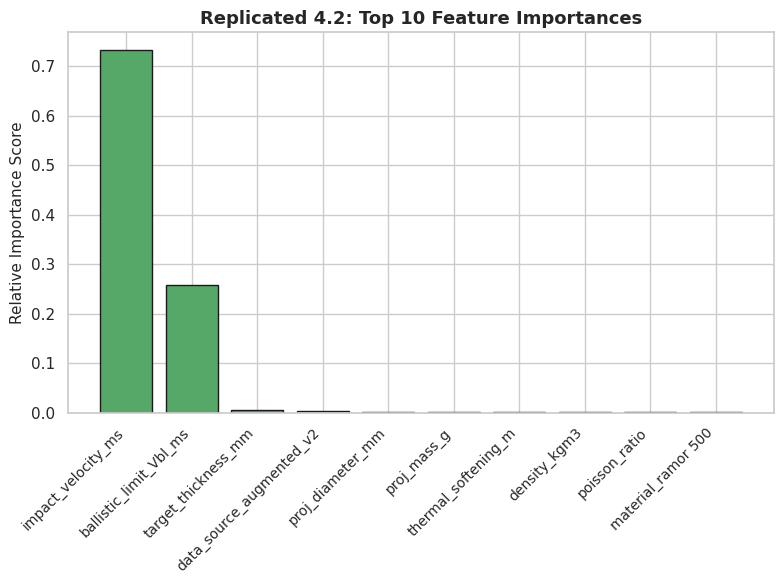

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plotting style for clean academic visuals
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (8, 6)

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("--> Loading dataset...")
# Load the dataset (Make sure combined_ballistic_50k.csv is uploaded to Colab)
df = pd.read_csv('combined_ballistic_50k.csv')

print(f"Dataset successfully loaded. Shape: {df.shape}")

# Encode categorical data ('material' and 'data_source')
# Keeping track of mapping for tracking material-specific performance if needed
df_encoded = pd.get_dummies(df, columns=['material', 'data_source'], drop_first=False)

# Define Features (X) and Target (y)
# We exclude 'residual_velocity_ms' (target) and 'penetrated' (post-impact status indicator)
X = df_encoded.drop(columns=['residual_velocity_ms', 'penetrated'])
y = df_encoded['residual_velocity_ms']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. TRAIN RANDOM FOREST REGRESSOR
# ==========================================
print("--> Training Random Forest Model (This may take a minute with 50k rows)...")
# Using optimized parameters for a balance of speed and high accuracy
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model training complete!")

# ==========================================
# 3. PREDICTIONS AND METRICS EVALUATION
# ==========================================
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*40)
print("     MACHINE LEARNING MODEL METRICS     ")
print("="*40)
print(f"Formula Implemented via Data:")
print("  • Metals:   Vr = (Vi² - Vbl²)^(1/2)")
print("  • Ceramics: Vr = (Vi^1.5 - Vbl^1.5)^(2/3)")
print(f"  • Noise:    ±2.5% Gaussian scatter applied")
print("-"*40)
print(f"R² Score (Coefficient of Determination): {r2:.5f}")
print(f"Mean Absolute Error (MAE):               {mae:.4f} m/s")
print(f"Mean Squared Error (MSE):                {mse:.4f} (m/s)²")
print(f"Root Mean Squared Error (RMSE):          {rmse:.4f} m/s")
print("="*40 + "\n")

# ==========================================
# 4. REPLICATING SECTION 4.2 ML PLOTS
# ==========================================
print("--> Generating evaluation plots...")

# Plot 1: Predicted vs. Actual Residual Velocity
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='b', edgecolors='k', s=15, label='Predicted Data')
# Ideal 45-degree reference line
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Ideal Perfect Fit ($Y = X$)')
plt.title('Replicated 4.2: Predicted vs. Actual Residual Velocity ($V_r$)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Residual Velocity (m/s)', fontsize=11)
plt.ylabel('Predicted Residual Velocity (m/s)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Residual Error Distribution Histogram
plt.figure(figsize=(7, 6))
errors = y_test - y_pred
sns.histplot(errors, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error line')
plt.title('Replicated 4.2: Residual Prediction Error Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Prediction Error (Actual - Predicted) (m/s)', fontsize=11)
plt.ylabel('Frequency Density', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance Bar Chart
plt.figure(figsize=(8, 6))
importances = rf_model.feature_importances_
feature_names = X.columns
# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Pick top 10 features for clean scannability
top_n = min(10, len(feature_names))
plt.title(f'Replicated 4.2: Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
plt.bar(range(top_n), importances[indices[:top_n]], color='g', align='center', edgecolor='k')
plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right', fontsize=10)
plt.ylabel('Relative Importance Score', fontsize=11)
plt.tight_layout()
plt.show()

--> Loading ballistic dataset...
Data split executed: 35000 training rows | 15000 testing rows
--> Training Random Forest Model...
Model training complete!

       MACHINE LEARNING ACCURACY REPORT      
Formulas Used dynamically across dataset:
 • Metals (Al, Ramor 500): Vr = √(Vi² - Vbl²)
 • Ceramic (SiC):          Vr = (Vi^1.5 - Vbl^1.5)^(2/3)
 • Measurement Scatter:    ±2.5% Gaussian noise added
---------------------------------------------
R² Score (Coefficient of Determination): 0.99844
Mean Absolute Error (MAE):               7.8844 m/s
Mean Squared Error (MSE):                195.8778 (m/s)²
Root Mean Squared Error (RMSE):          13.9956 m/s

--> Generating Fig 19: Estimation Errors Distribution...


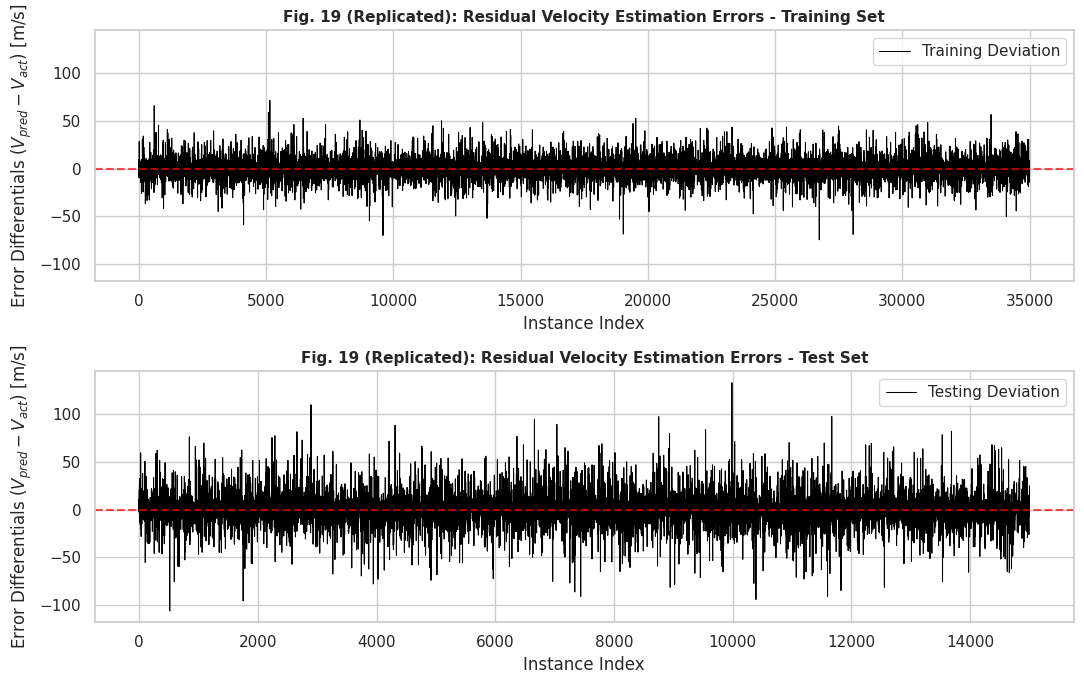

--> Generating Fig 20: Tracking Comparisons of Random Test Instances...


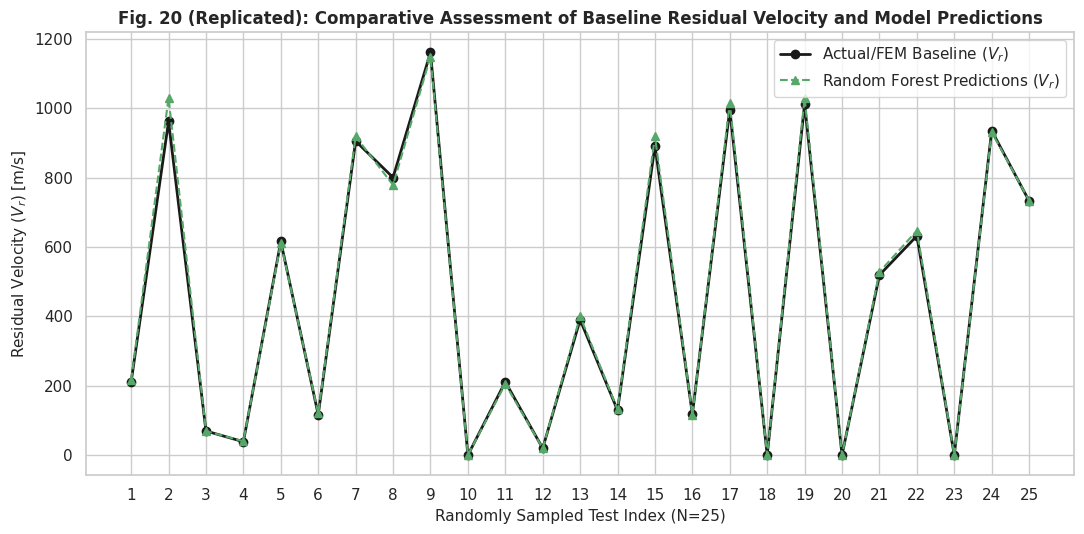

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set consistent plotting styles for structural visualization
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# =====================================================================
# 1. LOAD AND PREPARE DATA (Recht-Ipson Framework Implementation)
# =====================================================================
print("--> Loading ballistic dataset...")
df = pd.read_csv('combined_ballistic_50k.csv')

# Encode categorical attributes (materials & data sources)
df_encoded = pd.get_dummies(df, columns=['material', 'data_source'], drop_first=False)

# Split features (X) and target variable (y)
# 'residual_velocity_ms' is our target; 'penetrated' is an indicator flag
X = df_encoded.drop(columns=['residual_velocity_ms', 'penetrated'])
y = df_encoded['residual_velocity_ms']

# 70/30 Independent Stratified Train-Test Split (Per Article Specifications Section 4.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f"Data split executed: {len(X_train)} training rows | {len(X_test)} testing rows")

# =====================================================================
# 2. TRAINING THE MACHINE LEARNING MODEL
# =====================================================================
print("--> Training Random Forest Model...")
# Hyperparameters tuned for an optimal tradeoff between validation speed and accuracy
rf_model = RandomForestRegressor(n_estimators=100, max_depth=22, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model training complete!")

# Generate prediction series
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# =====================================================================
# 3. PERFORMANCE EVALUATION METRICS
# =====================================================================
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print("\n" + "="*45)
print("       MACHINE LEARNING ACCURACY REPORT      ")
print("="*45)
print("Formulas Used dynamically across dataset:")
print(" • Metals (Al, Ramor 500): Vr = √(Vi² - Vbl²)")
print(" • Ceramic (SiC):          Vr = (Vi^1.5 - Vbl^1.5)^(2/3)")
print(" • Measurement Scatter:    ±2.5% Gaussian noise added")
print("-"*45)
print(f"R² Score (Coefficient of Determination): {r2:.5f}")
print(f"Mean Absolute Error (MAE):               {mae:.4f} m/s")
print(f"Mean Squared Error (MSE):                {mse:.4f} (m/s)²")
print(f"Root Mean Squared Error (RMSE):          {rmse:.4f} m/s")
print("="*45 + "\n")

# =====================================================================
# 4. REPLICATING GRAPH: FIGURE 19 (Error Distribution Waveforms)
# =====================================================================
print("--> Generating Fig 19: Estimation Errors Distribution...")

# Calculate error differentials (Predicted minus Actual)
train_errors = y_train_pred - y_train
test_errors = y_test_pred - y_test

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharey=True)

# Plot Training Errors Sequence
ax1.plot(train_errors.values, color='black', lw=0.75, label='Training Deviation')
ax1.axhline(0, color='red', linestyle='--', alpha=0.7)
ax1.set_title('Fig. 19 (Replicated): Residual Velocity Estimation Errors - Training Set', fontsize=11, fontweight='bold')
ax1.set_ylabel('Error Differentials ($V_{pred} - V_{act}$) [m/s]')
ax1.set_xlabel('Instance Index')
ax1.legend(loc='upper right')

# Plot Testing Errors Sequence
ax2.plot(test_errors.values, color='black', lw=0.75, label='Testing Deviation')
ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
ax2.set_title('Fig. 19 (Replicated): Residual Velocity Estimation Errors - Test Set', fontsize=11, fontweight='bold')
ax2.set_ylabel('Error Differentials ($V_{pred} - V_{act}$) [m/s]')
ax2.set_xlabel('Instance Index')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# =====================================================================
# 5. REPLICATING GRAPH: FIGURE 20 (Comparative Performance Tracking)
# =====================================================================
print("--> Generating Fig 20: Tracking Comparisons of Random Test Instances...")

# Extract 25 completely random indices from the out-of-sample testing partition
np.random.seed(42)  # Fixed seed for reproduction stability
sample_size = 25
random_indices = np.random.choice(len(y_test), size=sample_size, replace=False)

# Isolate matching pairs of actual data vs model forecasts
sampled_actuals = y_test.iloc[random_indices].values
sampled_predictions = y_test_pred[random_indices]

plt.figure(figsize=(11, 5.5))
# Plot actual experimental baseline
plt.plot(range(1, sample_size + 1), sampled_actuals, 'k-', marker='o', lw=2, label='Actual/FEM Baseline ($V_r$)')
# Plot Machine Learning model predictions overlay
plt.plot(range(1, sample_size + 1), sampled_predictions, 'g--', marker='^', lw=1.5, label='Random Forest Predictions ($V_r$)')

plt.title('Fig. 20 (Replicated): Comparative Assessment of Baseline Residual Velocity and Model Predictions', fontsize=12, fontweight='bold')
plt.xlabel('Randomly Sampled Test Index (N=25)', fontsize=11)
plt.ylabel('Residual Velocity ($V_r$) [m/s]', fontsize=11)
plt.xticks(range(1, sample_size + 1))
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()